In [41]:
import numpy as np
import torch
import torch.nn as nn
import openml
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold

import optuna


plt.style.use("default")

In [42]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [43]:
dataset = openml.datasets.get_dataset("liver-disorders").get_data()[0]
TARGET_COL = "drinks"
X = torch.tensor(dataset[dataset.columns.drop(TARGET_COL)].to_numpy(), dtype=torch.float).to(device)
y = torch.tensor(dataset[TARGET_COL].to_numpy(), dtype=torch.float).reshape(-1, 1).to(device)

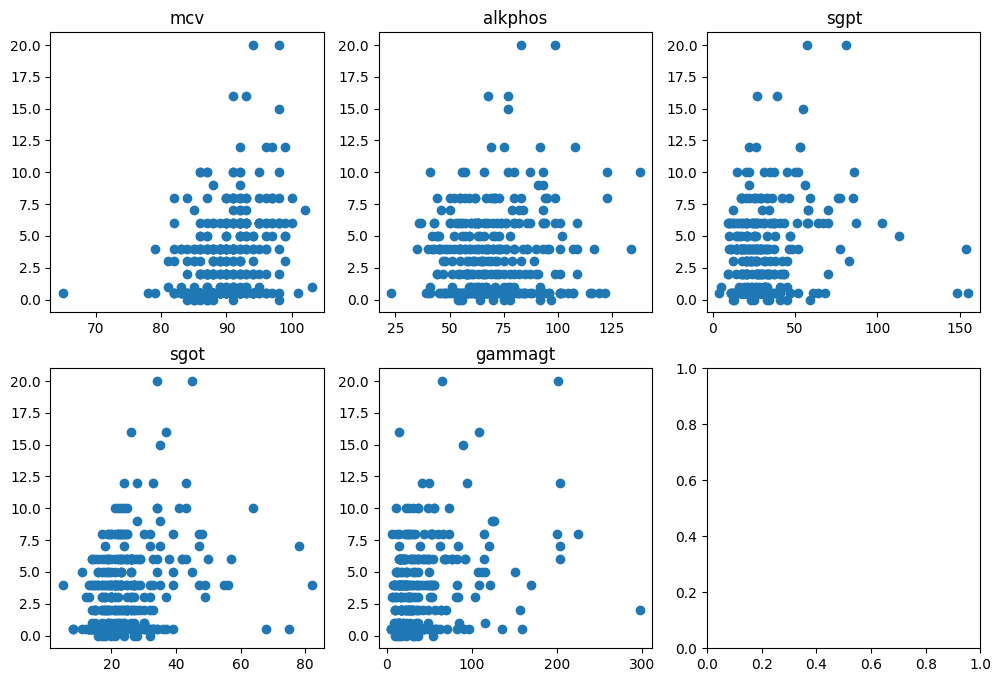

In [44]:
fig, axs = plt.subplots(2, 3, figsize=(12, 8))
axs = axs.flatten()

for i in range(X.shape[1]):
    ax = axs[i]
    ax.scatter(X.cpu()[:, i], y.cpu())
    ax.set_title(dataset.columns.drop(TARGET_COL)[i])

In [45]:
class MLP(nn.Module):
    def __init__(self, n_hidden: int, n_width: int):
        super().__init__()

        self.input_layer = nn.Linear(X.shape[1], n_width)
        self.hidden_layers = nn.ModuleList([nn.Linear(n_width, n_width) for _ in range(n_hidden)])
        self.output_layer = nn.Linear(n_width, 1)
        self.relu = nn.ReLU()

        self.train_losses = []
        self.test_losses = []
        self.train_rsq = []
        self.test_rsq = []
        self.best_test_loss = -1

    def forward(self, x):
        x = self.relu(self.input_layer(x))

        for layer in self.hidden_layers:
            x = self.relu(layer(x))

        x = self.output_layer(x)
        return x

In [51]:
def train_new_model(fold: int, n_hidden: int, n_width: int, n_epochs: int, X_train, y_train, X_test, y_test):
    model = MLP(n_hidden, n_width).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    best_loss = 99999999.9

    for epoch in range(n_epochs):
        optimizer.zero_grad()
        model.train()

        y_pred = model(X_train)
        loss = loss_fn(y_pred, y_train)

        loss.backward()
        optimizer.step()

        model.train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            y_pred = model(X_test)
            loss = loss_fn(y_pred, y_test)
            model.test_losses.append(loss.item())

            if loss < best_loss:
                best_loss = loss.item()
                model.best_test_loss = best_loss
                torch.save(model.state_dict(), f"checkpoints/fold{fold}_best.pth")

    best_chkpt = torch.load(f"checkpoints/fold{fold}_best.pth")
    model.load_state_dict(best_chkpt)
    return model


In [47]:
def train_k_fold_models(n_hidden: int, n_width: int, n_epochs: int) -> list[MLP]:
    kf = KFold(n_splits=5, shuffle=True)

    k_models = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(X, y)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model = train_new_model(fold, n_hidden, n_width, n_epochs, X_train, y_train, X_test, y_test)
        k_models.append(model)

    return k_models

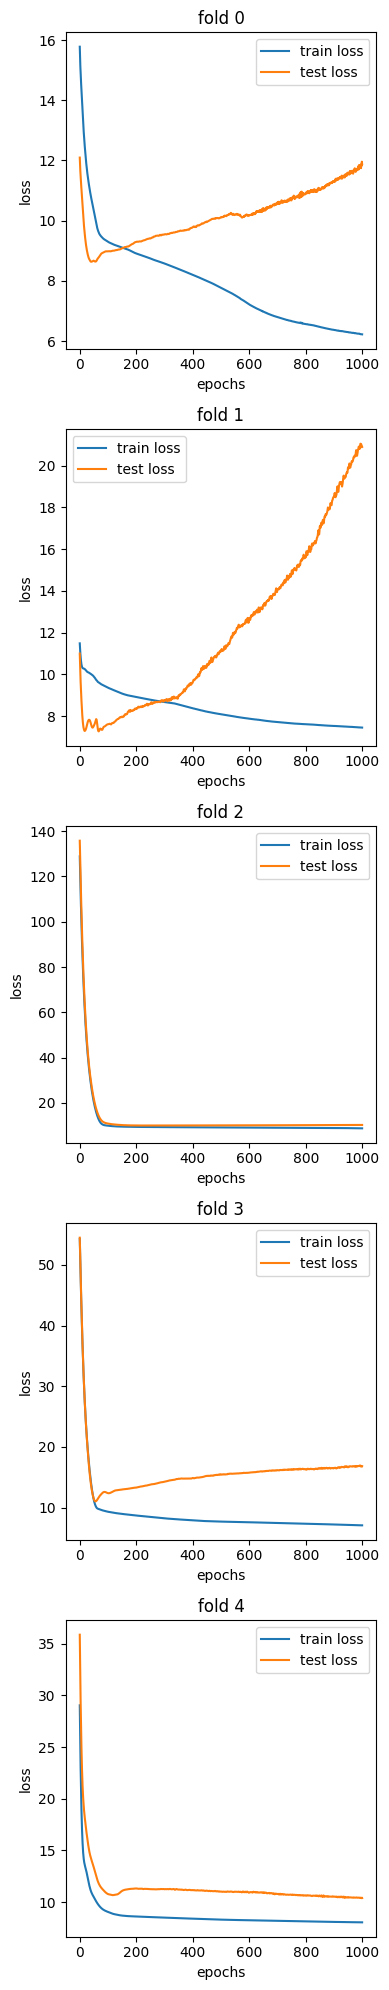

In [48]:
k_models = train_k_fold_models(1, 10, 1000)

fig, axs = plt.subplots(len(k_models), 1, figsize=(4, 4*len(k_models)))
axs = axs.reshape(len(k_models), -1)

for idx, model in enumerate(k_models):
    ax = axs[idx, 0]

    epochs_axis = np.arange(len(model.train_losses))
    ax.plot(epochs_axis, model.train_losses, label="train loss")
    ax.plot(epochs_axis, model.test_losses, c="tab:orange", label="test loss")
    ax.set_xlabel("epochs")
    ax.set_ylabel("loss")
    ax.legend()

    ax.set_title(f"fold {idx}")

plt.tight_layout()
plt.show()

In [49]:
def objective_shape(trial):
    n_hidden = trial.suggest_int("n_hidden", 1, 10)
    n_width = trial.suggest_int("n_width", 3, 30, log=True)

    k_models = train_k_fold_models(n_hidden, n_width, 1000)
    mean_loss = np.mean([m.best_test_loss for m in k_models])

    return mean_loss

In [52]:
shape_opt_study = optuna.create_study(study_name="OptimizeShape", direction="minimize")
shape_opt_study.optimize(objective_shape, n_trials=50)

[I 2026-04-17 20:55:26,528] A new study created in memory with name: OptimizeShape
[I 2026-04-17 20:55:36,247] Trial 0 finished with value: 10.185663032531739 and parameters: {'n_hidden': 3, 'n_width': 4}. Best is trial 0 with value: 10.185663032531739.
[I 2026-04-17 20:55:55,507] Trial 1 finished with value: 13.9495135307312 and parameters: {'n_hidden': 9, 'n_width': 4}. Best is trial 0 with value: 10.185663032531739.
[I 2026-04-17 20:56:10,810] Trial 2 finished with value: 9.311866092681885 and parameters: {'n_hidden': 10, 'n_width': 19}. Best is trial 2 with value: 9.311866092681885.
[I 2026-04-17 20:56:25,679] Trial 3 finished with value: 9.454206275939942 and parameters: {'n_hidden': 9, 'n_width': 13}. Best is trial 2 with value: 9.311866092681885.
[I 2026-04-17 20:56:34,222] Trial 4 finished with value: 9.515719413757324 and parameters: {'n_hidden': 3, 'n_width': 30}. Best is trial 2 with value: 9.311866092681885.
[I 2026-04-17 20:56:43,226] Trial 5 finished with value: 9.6814744

In [54]:
shape_opt_study.best_params

{'n_hidden': 8, 'n_width': 26}